## Plot MUSICAv0 fv01 data
- This script is used to visualize MUSICAv0 fv01 distributions of O3 and PM2.5

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))
import glob
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from zhiyi.plot.cbar import Cbar


In [ ]:

# var_name = "PM25"
var_name = "O3"

# MetOffice gpkg 
met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg"
# met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg"

# MUSICA fv0.1 dir
data_dir_musica = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regirdded_fv01"
files_musica = (
    sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2017-12.nc"))
    + sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2018-??.nc"))
)

# Natural Earth shapefile
ne_shp = "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"

gdf = gpd.read_file(met_gpkg)
gdf["stdTime"] = pd.to_datetime(gdf["stdTime"])

start = pd.Timestamp("2017-12-01", tz="UTC")
end   = pd.Timestamp("2018-12-01", tz="UTC")
mask_time = (gdf["stdTime"] >= start) & (gdf["stdTime"] < end)
gdf_sel = gdf.loc[mask_time].copy()

gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(
    mean_avg=("mean", "mean")
)

gdf_avg = gdf_avg.merge(
    gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
    on="gridID",
    how="left"
)
gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

bounds = gdf_avg.geometry.bounds  # minx,miny,maxx,maxy
gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

df = gdf_avg[["lon", "lat", "mean_avg"]].copy()
pivot = df.pivot(index="lat", columns="lon", values="mean_avg")

lat_centers = pivot.index.values.astype(float)
lon_centers = pivot.columns.values.astype(float)

dlon = np.median(np.diff(lon_centers))
dlat = np.median(np.diff(lat_centers))

lon_edges = np.concatenate((
    [lon_centers[0] - dlon/2],
    (lon_centers[1:] + lon_centers[:-1]) / 2,
    [lon_centers[-1] + dlon/2]
))
lat_edges = np.concatenate((
    [lat_centers[0] - dlat/2],
    (lat_centers[1:] + lat_centers[:-1]) / 2,
    [lat_centers[-1] + dlat/2]
))

lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)
lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

ne_admin1 = gpd.read_file(ne_shp)
if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)

# ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IRL", "IMN"])]
ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]

uk_ie_union = ne_uk_ie.union_all()
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
    crs="EPSG:4326"
)
inside = points.within(uk_ie_union).values
mask_land = inside.reshape(lonc2d.shape)

ds_mus = xr.open_mfdataset(files_musica, combine="by_coords")

# lon 0–360 to -180-180
lons_raw = ds_mus["lon"]
lons_deg = xr.where(lons_raw > 180, lons_raw - 360, lons_raw)
ds_mus = ds_mus.assign_coords(lon=lons_deg)
ds_mus = ds_mus.sortby("lon")
factor_mus = 1e9 * 2.04   #ppbv to ug/m3  
var3d = ds_mus[var_name] * factor_mus
var_sfc = var3d.isel(lev=-1)
var_mean = var_sfc.mean(dim="time")

var_on_met = var_mean.interp(
    lat=lat_centers,
    lon=lon_centers) 

data2d_mus = var_on_met.values
data2d_mus_masked = np.where(mask_land, data2d_mus, np.nan)

cbar_main = Cbar("myct_cont")
cmap_main = cbar_main.cmap

def plot_map(ax, data2d_masked, cmap, vmin=None, vmax=None, title=""):
    proj = ccrs.PlateCarree()
    pcm = ax.pcolormesh(
        lon2d, lat2d, data2d_masked,
        shading="auto",
        transform=proj,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    ax.set_extent([-10, 2, 50, 59], crs=proj)
    ax.coastlines("10m", linewidth=0.25)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.25)

    ax.add_geometries(
        ne_uk_ie.geometry,
        crs=proj,
        facecolor="none",
        edgecolor="black",
        linewidth=0.3
    )

    xticks = np.arange(-10.5, 3, 2)
    yticks = np.arange(49.5, 62, 2)
    ax.set_xticks(xticks, crs=proj)
    ax.set_yticks(yticks, crs=proj)

    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

    ax.set_title(title, fontsize=9)

    return pcm


/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-11-16T00:00:00.0Z, successfully parsed
  return ogr_read(


Text(0.02, 0.98, '(a)')

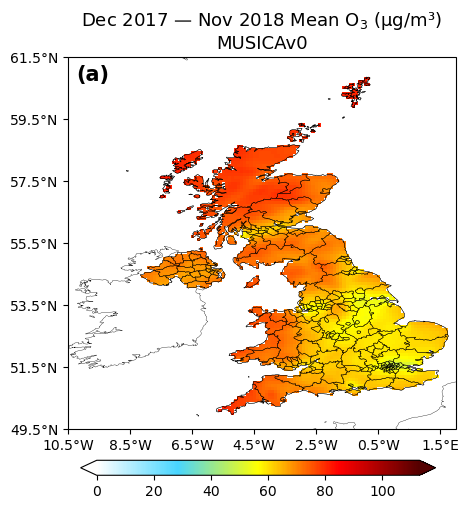

In [ ]:

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(
    1, 1, figsize=(5, 5),
    subplot_kw={"projection": proj}
)

pcm = plot_map(
    ax,
    data2d_mus_masked,
    cmap=cmap_main,
    vmin=0, 
    vmax=113 #O3
)

cax = fig.add_axes([0.15, 0.03, 0.71, 0.03]) 
cb = plt.colorbar(pcm, cax=cax, orientation="horizontal", extend="both")
# cb.set_label("O$_3$ (ppbv)")  
# ax.set_title("Dec 2017 — Nov 2018 Mean PM$_{2.5}$ (µg/m³) \nMUSICAv0", fontsize=13)
ax.set_title("Dec 2017 — Nov 2018 Mean O$_{3}$ (µg/m³) \nMUSICAv0", fontsize=13)

ax.text(
    0.02, 0.98, "(a)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15,
    fontweight="bold"
)


In [ ]:

var_name = "PM25"
# var_name = "O3"

# MetOffice gpkg 
# met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_Ozone_Gridded_-4374955293643276370.gpkg"
met_gpkg = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/MetOffice/Monthly_Mean_PM2p5_Gridded_3075619853497766146.gpkg"

# MUSICA fv0.1 dir
data_dir_musica = "/home/users/zhiyi/duicv/ZHIYI_SOO/P_1/regrid/regirdded_fv01"
files_musica = (
    sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2017-12.nc"))
    + sorted(glob.glob(f"{data_dir_musica}/MUSICA_fv01_MUSICA_production3.2_BB.cam.h4.2018-??.nc"))
)

# Natural Earth shapefile
ne_shp = "/home/users/zhiyi/PROJECTS_ANALYSIS/shap_file/natural_earth/ne_10m_admin_1_states_provinces.shp"

gdf = gpd.read_file(met_gpkg)
gdf["stdTime"] = pd.to_datetime(gdf["stdTime"])

start = pd.Timestamp("2017-12-01", tz="UTC")
end   = pd.Timestamp("2018-12-01", tz="UTC")
mask_time = (gdf["stdTime"] >= start) & (gdf["stdTime"] < end)
gdf_sel = gdf.loc[mask_time].copy()

gdf_avg = gdf_sel.groupby("gridID", as_index=False).agg(
    mean_avg=("mean", "mean")
)

gdf_avg = gdf_avg.merge(
    gdf.drop_duplicates("gridID")[["gridID", "geometry"]],
    on="gridID",
    how="left"
)
gdf_avg = gpd.GeoDataFrame(gdf_avg, geometry="geometry")

bounds = gdf_avg.geometry.bounds  # minx,miny,maxx,maxy
gdf_avg["lon"] = (bounds["minx"] + bounds["maxx"]) / 2
gdf_avg["lat"] = (bounds["miny"] + bounds["maxy"]) / 2

df = gdf_avg[["lon", "lat", "mean_avg"]].copy()
pivot = df.pivot(index="lat", columns="lon", values="mean_avg")

lat_centers = pivot.index.values.astype(float)
lon_centers = pivot.columns.values.astype(float)

dlon = np.median(np.diff(lon_centers))
dlat = np.median(np.diff(lat_centers))

lon_edges = np.concatenate((
    [lon_centers[0] - dlon/2],
    (lon_centers[1:] + lon_centers[:-1]) / 2,
    [lon_centers[-1] + dlon/2]
))
lat_edges = np.concatenate((
    [lat_centers[0] - dlat/2],
    (lat_centers[1:] + lat_centers[:-1]) / 2,
    [lat_centers[-1] + dlat/2]
))

lon2d, lat2d = np.meshgrid(lon_edges, lat_edges)
lonc2d, latc2d = np.meshgrid(lon_centers, lat_centers)

ne_admin1 = gpd.read_file(ne_shp)
if ne_admin1.crs is None or ne_admin1.crs.to_epsg() != 4326:
    ne_admin1 = ne_admin1.to_crs(epsg=4326)

# ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IRL", "IMN"])]
ne_uk_ie = ne_admin1[ne_admin1["adm0_a3"].isin(["GBR", "IMN"])]

uk_ie_union = ne_uk_ie.union_all()
points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lonc2d.ravel(), latc2d.ravel()),
    crs="EPSG:4326"
)
inside = points.within(uk_ie_union).values
mask_land = inside.reshape(lonc2d.shape)

ds_mus = xr.open_mfdataset(files_musica, combine="by_coords")

# lon 0–360 to -180-180
lons_raw = ds_mus["lon"]
lons_deg = xr.where(lons_raw > 180, lons_raw - 360, lons_raw)
ds_mus = ds_mus.assign_coords(lon=lons_deg)
ds_mus = ds_mus.sortby("lon")
factor_mus = 1e9 

var3d = ds_mus[var_name] * factor_mus
var_sfc = var3d.isel(lev=-1)
var_mean = var_sfc.mean(dim="time")

var_on_met = var_mean.interp(
    lat=lat_centers,
    lon=lon_centers) 

data2d_mus = var_on_met.values
data2d_mus_masked = np.where(mask_land, data2d_mus, np.nan)

cbar_main = Cbar("myct_cont")
cmap_main = cbar_main.cmap

def plot_map(ax, data2d_masked, cmap, vmin=None, vmax=None, title=""):
    proj = ccrs.PlateCarree()
    pcm = ax.pcolormesh(
        lon2d, lat2d, data2d_masked,
        shading="auto",
        transform=proj,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_extent([-10, 2, 50, 59], crs=proj)
    ax.coastlines("10m", linewidth=0.25)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.25)
    ax.add_geometries(
        ne_uk_ie.geometry,
        crs=proj,
        facecolor="none",
        edgecolor="black",
        linewidth=0.3
    )

    xticks = np.arange(-10.5, 3, 2)
    yticks = np.arange(49.5, 62, 2)
    ax.set_xticks(xticks, crs=proj)
    ax.set_yticks(yticks, crs=proj)

    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())

    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

    ax.set_title(title, fontsize=9)

    return pcm


/home/users/zhiyi/.conda/envs/plot_musica/lib/python3.9/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column stdTime, 2017-12-16T12:00:00.0Z, successfully parsed
  return ogr_read(


Text(0.02, 0.98, '(e)')

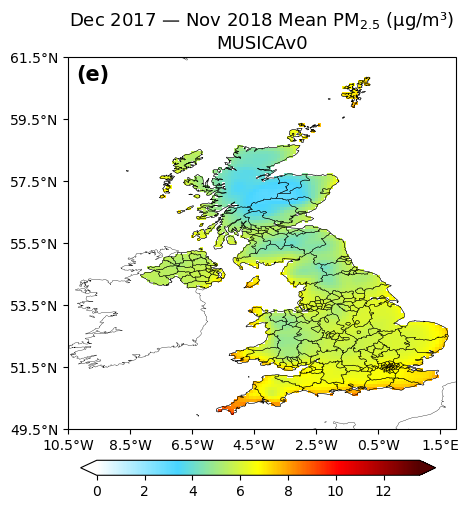

In [ ]:

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(
    1, 1, figsize=(5, 5),
    subplot_kw={"projection": proj}
)

pcm = plot_map(
    ax,
    data2d_mus_masked,
    cmap=cmap_main,
    vmin=0, 
    vmax=13.5  
)

cax = fig.add_axes([0.15, 0.03, 0.71, 0.03])
cb = plt.colorbar(pcm, cax=cax, orientation="horizontal", extend="both")
# cb.set_label("O$_3$ (ppbv)")  
ax.set_title("Dec 2017 — Nov 2018 Mean PM$_{2.5}$ (µg/m³) \nMUSICAv0", fontsize=13) 
# ax.set_title("Dec 2017 — Nov 2018 Mean O$_{3}$ (µg/m³) \nMUSICAv0", fontsize=13)

ax.text(
    0.02, 0.98, "(e)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=15,
    fontweight="bold"
)
